# Agents Lab — Constructing a Goal-Based Agent with an LLM

**Course:** CS F407 — Artificial Intelligence · **Lab:** Agents
**Handout:** `agents_lab.pdf`

---

## What this notebook does

The handout asks for a goal-based agent that navigates a warehouse grid from `S`
to `G`. The programming is not the point — the point is specifying the problem,
designing the agent, using an LLM to implement it, and then *testing* what comes
back.

So this notebook keeps one rule: **every claim is backed by something that runs.**
In particular, the handout's Task 1 question 5 — "why is this a goal-based agent
rather than a simple reflex agent?" — is usually answered with a paragraph. Here
it is answered with an experiment: a simple reflex agent is actually implemented
and run on the same map, and the notebook shows exactly where and why it fails.

The "Think About It" question about doubling the warehouse size is likewise
answered by measurement rather than speculation: the agent is run on a family of
warehouses of growing size and the cost curve is fitted.

In [1]:
"""Environment, agent scaffolding, and shared plotting style."""
import random
import time
from collections import deque
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# ---- the warehouse map exactly as printed in the handout ---------------------
WAREHOUSE = """\
#####################
#S....#............G#
#.##....##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################"""

# ---- design tokens (CVD-validated categorical slots, fixed order) ------------
SERIES = {"goal-based (BFS)": "#2a78d6", "simple reflex": "#eb6834",
          "goal-based (DFS)": "#1baf7a"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#8a8880",
       "grid": "#e6e5e1", "surface": "#fcfcfb"}
CELL_COLORS = {"free": "#fcfcfb", "wall": "#d8d7d2", "path": "#9ec5f4",
               "start": "#1baf7a", "goal": "#e34948", "visited": "#eef4fd"}

mpl.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"],
    "axes.edgecolor": INK["grid"], "axes.linewidth": 1.0,
    "axes.labelcolor": INK["secondary"], "axes.titlecolor": INK["primary"],
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": INK["grid"], "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "legend.labelcolor": INK["secondary"],
    "lines.linewidth": 2.0, "lines.markersize": 8, "figure.dpi": 130,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
        ax.set_axisbelow(True)
    return ax

print(WAREHOUSE)
rows = WAREHOUSE.splitlines()
print(f"\nGrid: {len(rows)} rows x {len(rows[0])} columns = {len(rows) * len(rows[0])} cells")
print("Free cells:", sum(ch != '#' for r in rows for ch in r))

#####################
#S....#............G#
#.##....##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################

Grid: 7 rows x 21 columns = 147 cells
Free cells: 66


---

## Task 1 — Understanding the problem

### 1. What is the environment?

A 7 × 21 rectangular grid of cells, each either **free** (`.`, `S`, `G`) or an
**obstacle** (`#`). The vehicle occupies exactly one free cell at a time. Using
the standard AIMA task-environment vocabulary, the environment is:

| Property | This warehouse | Why it matters |
|---|---|---|
| Fully observable | yes — the whole map is known in advance | the agent can plan offline; no exploration needed |
| Deterministic | yes — each move has one certain outcome | a plan made now stays valid when executed |
| Static | yes — shelves do not move while the agent deliberates | no need to re-plan mid-execution |
| Discrete | yes — finite cells, four actions | search over a finite graph terminates |
| Single-agent | yes | no other vehicle to model or avoid |
| Sequential | yes — early moves constrain later ones | a greedy one-step choice can be a trap |

That combination is precisely what makes offline search the right technique: the
agent can compute a complete path *before* moving, and nothing will invalidate it.

### 2. What is the goal of the agent?

To be at the cell marked `G`. Formally the goal is the single-state predicate
$\text{Goal}(s) \equiv (s = \text{pos}_G)$. Two things are deliberately *not*
part of the goal: any particular route, and any notion of speed. Anything that
ends at `G` satisfies it — which is why the goal alone does not determine
behaviour, and a cost measure has to be added to prefer shorter routes.

### 3. What actions are available?

Four: **Up, Down, Left, Right**, each moving one cell. An action is *valid* only
if the destination is inside the grid and is not a `#`. Invalid actions are not
"allowed but bad" — they are removed from the successor function entirely, which
is what keeps obstacles from ever being crossed.

### 4. What must the agent maintain to choose its next action?

| Information | Purpose | Consequence if omitted |
|---|---|---|
| Current position | the state itself | no notion of where it is |
| The map | to compute valid moves | it would walk into shelves |
| Goal position | the goal test | it could never terminate |
| **Set of visited cells** | avoid re-expanding states | infinite loops in a cyclic grid |
| **Frontier of cells to explore** | remember alternatives not yet tried | cannot back out of a dead end |
| **Parent pointers** | reconstruct the path once `G` is found | knows the goal is reachable but not how |

The last three are the interesting ones. They are exactly the internal state a
*reflex* agent does not have, which is the subject of question 5.

### 5. Why goal-based rather than simple reflex?

A simple reflex agent maps the current percept to an action through fixed
condition–action rules. It has no memory of where it has been and no model of
where its actions lead, so it cannot represent "this corridor is a dead end" or
"I have been here before". On a grid with concave obstacles, the natural reflex
rule — *move in the direction that reduces distance to the goal* — reaches a
local minimum where no move improves the distance, and from there it cycles:
because the rule is a pure function of the current cell, revisiting a cell
reproduces exactly the decision that led away from it. The notebook prints the
rule's own view at the cells where this happens.

A goal-based agent, by contrast, keeps an explicit goal and an internal model of
the environment, and it *searches* — it considers sequences of actions and their
consequences before committing. That lets it accept a temporarily worse position
in exchange for a route that eventually reaches `G`.

This is a testable claim rather than a rhetorical one, so the notebook tests it
below: both agents are implemented and run on the same map.

---

## Task 2 — Designing the agent

### Block diagram

```
                        +---------------------------------------+
                        |          GOAL-BASED AGENT             |
                        |                                       |
   percept              |   +-----------------+                 |
   (position) --------->|-->|  State          |  "where am I?"  |
                        |   |  current cell   |                 |
                        |   +--------+--------+                 |
                        |            |                          |
                        |            v                          |
                        |   +-----------------+                 |
                        |   |  Model          |  "what happens  |
                        |   |  grid + actions |   if I move?"   |
                        |   +--------+--------+                 |
                        |            |                          |
                        |            v                          |
                        |   +-----------------+                 |
                        |   |  Goal           |  "where do I    |
                        |   |  cell G         |   want to be?"  |
                        |   +--------+--------+                 |
                        |            |                          |
                        |            v                          |
                        |   +-----------------------------+     |
                        |   |  DECISION COMPONENT         |     |
                        |   |  search (BFS) over          |     |
                        |   |  frontier + visited +       |     |
                        |   |  parent pointers            |     |
                        |   +--------------+--------------+     |
                        |                  |                    |
                        +------------------|--------------------+
                                           v
                                        action
                                   (Up/Down/Left/Right)
                                           |
                                           v
                        +---------------------------------------+
                        |   ENVIRONMENT: 7 x 21 warehouse grid  |
                        +---------------------------------------+
                                           |
                                           +--> new percept (loop back to State)
```

The **model** box is what a reflex agent lacks: without it there is no way to ask
"what would happen if…", so the only thing left is to react to the present cell.

### Design decisions, made before prompting

| Component | Choice | Reason |
|---|---|---|
| Environment representation | tuple of strings, parsed once into a `frozenset` of walls | immutable, hashable, cheap membership test |
| State | `(row, col)` tuple | fully captures the situation; hashable so it can go in a `set` |
| Actions | fixed order `Up, Down, Left, Right` | deterministic tie-breaking, so runs are reproducible |
| Search | **BFS** | all moves cost 1, so BFS is optimal *and* needs no priority queue |
| Frontier | `collections.deque` | O(1) popleft; a `list.pop(0)` would make it O(n) |
| Visited | `set`, marked **when enqueued** | marking on dequeue lets duplicates pile up in the frontier |
| Path recovery | `parent` dict, walked back from `G` | avoids storing a full path per frontier entry |

Two of these are the kind of detail an LLM commonly gets wrong, and both are
checked explicitly in Task 3.

### Think About It — what if the warehouse doubled in size?

BFS would still be *correct* — it is complete and optimal for unit costs
regardless of scale. What degrades is cost. BFS explores in expanding rings, so
on a grid it touches a number of cells proportional to the area it covers. Double
both dimensions and the area quadruples, so both time and memory roughly
quadruple; memory is the binding constraint, because the frontier and the
visited set must both be held.

The fix is not a faster computer but a *better-informed* algorithm: A\* with a
Manhattan heuristic explores preferentially toward the goal instead of in all
directions, usually expanding far fewer cells for the same optimal answer. That
is exactly the subject of the Search lab. Other difficulties that appear at
scale: dynamic obstacles (other vehicles), which break the static assumption and
force re-planning; and non-uniform costs (turning, congestion), which break BFS's
optimality guarantee and require Dijkstra or A\*.

This is measured at the end of the notebook rather than asserted.

In [2]:
@dataclass(frozen=True)
class Warehouse:
    """The environment: an immutable grid with a start and a goal cell."""
    walls: frozenset
    n_rows: int
    n_cols: int
    start: tuple
    goal: tuple

    @classmethod
    def parse(cls, text):
        rows = text.strip("\n").splitlines()
        walls, start, goal = set(), None, None
        for r, line in enumerate(rows):
            for c, ch in enumerate(line):
                if ch == "#":
                    walls.add((r, c))
                elif ch == "S":
                    start = (r, c)
                elif ch == "G":
                    goal = (r, c)
        if start is None or goal is None:
            raise ValueError("map must contain both S and G")
        return cls(frozenset(walls), len(rows), max(len(l) for l in rows), start, goal)

    def passable(self, cell):
        r, c = cell
        return 0 <= r < self.n_rows and 0 <= c < self.n_cols and cell not in self.walls

    def actions(self, cell):
        """Valid (action_name, next_cell) pairs. Invalid moves are never offered."""
        r, c = cell
        candidates = [("Up", (r - 1, c)), ("Down", (r + 1, c)),
                      ("Left", (r, c - 1)), ("Right", (r, c + 1))]
        return [(name, nxt) for name, nxt in candidates if self.passable(nxt)]

    def is_goal(self, cell):
        return cell == self.goal


warehouse = Warehouse.parse(WAREHOUSE)
print(f"start S = {warehouse.start}   goal G = {warehouse.goal}")
print(f"grid {warehouse.n_rows} x {warehouse.n_cols}, {len(warehouse.walls)} obstacle cells")
print(f"actions available at S: {[a for a, _ in warehouse.actions(warehouse.start)]}")
print(f"actions available at G: {[a for a, _ in warehouse.actions(warehouse.goal)]}")

start S = (1, 1)   goal G = (1, 19)
grid 7 x 21, 81 obstacle cells
actions available at S: ['Down', 'Right']
actions available at G: ['Down', 'Left']


---

## Task 3 — Prompt engineering

### The prompt I used

> Write a well-documented Python implementation of a **goal-based agent** for a
> warehouse navigation problem, following this specification exactly.
>
> **Environment.** An ASCII grid passed in as a string. `#` is an obstacle, `.`
> is free, `S` is the start, `G` is the goal. Parse it into an immutable object
> exposing `actions(cell)` (returning only *valid* `(name, next_cell)` pairs) and
> `is_goal(cell)`. Do not let the agent ever occupy a `#` cell.
>
> **Agent.** A state is a `(row, col)` tuple. Use **breadth-first search** —
> every move costs 1, so BFS is optimal and a priority queue is unnecessary.
> Justify that choice in a comment.
>
> **Required implementation details**, because these are the things I want to
> check rather than assume:
> - the frontier must be a `collections.deque` used with `popleft()`, not a list
>   with `pop(0)`;
> - a cell must be marked visited **when it is enqueued**, not when it is
>   dequeued;
> - generate successors in the fixed order Up, Down, Left, Right so runs are
>   reproducible;
> - reconstruct the path from a `parent` dictionary rather than storing a whole
>   path on every frontier entry.
>
> **Return** a result object carrying: whether a path was found, the path as a
> list of cells, the list of action names, the path length in moves, the number
> of nodes *expanded*, and the maximum frontier size. If no path exists, return
> the failure result rather than raising or looping forever.
>
> Also write a **simple reflex agent** for comparison: no memory and no search,
> just the condition–action rule "take the valid move that most reduces Manhattan
> distance to the goal, breaking ties in the fixed action order." Give it a step
> limit and report whether it reached the goal, so I can demonstrate where a
> reflex agent fails.

### Why this prompt rather than "write a program"

Every bullet is a decision I had already made in Task 2. That matters for two
reasons. It makes the output *checkable* — I can read the code against a list I
wrote beforehand, instead of judging whether it "looks right". And it stops the
LLM from silently substituting its own design: asked vaguely, models reach for
A\* here because the word "navigation" co-occurs with A\* in training data, even
though on a unit-cost grid with no heuristic requested, BFS is simpler and
equally optimal.

### Answers to the handout's Task 3 questions

**1. Did the LLM generate a working program on the first attempt?**
It ran without error and returned a valid path on the first attempt — but "runs"
and "correct" are different claims, and two of the required details were wrong.
See the corrections below.

**2. How can the prompt be improved?** The version above is already the improved
one. My first attempt just described the problem and asked for a goal-based
agent; it returned A\* with an unexplained heuristic and a `path` list copied
onto every frontier entry (quadratic memory). Naming the algorithm, the data
structures, and the reporting requirements is what removed the ambiguity.

**3. What search algorithm did the LLM choose?** BFS, because I specified it.
Left unconstrained it chose A\* with Manhattan distance.

**4. Why did it select that algorithm?** Not from analysis of the cost structure.
Grid navigation is overwhelmingly presented with A\* in the material these models
are trained on, so A\* is the high-probability completion. It is not a *wrong*
choice — A\* with an admissible heuristic is also optimal — but the reasoning
offered for it ("A\* is efficient for pathfinding") was a generic justification
rather than one derived from this problem's uniform unit costs.

### Corrections I made to the generated code

1. **Visited marking was on dequeue, not enqueue.** The draft appended a cell to
   the frontier and only added it to `visited` after popping it. On a grid with
   cycles the same cell then gets enqueued several times before it is first
   expanded; the answer is still correct, but the frontier grows and the expansion
   count is inflated. Moved the marking to enqueue time.
2. **The reported "expanded" count included the goal check ordering.** The draft
   incremented its counter for every cell *generated* and called it "nodes
   expanded". Those are different measures, and the BFS/A\* comparison in the
   Search lab is meaningless if they are confused. Separated `n_expanded`
   (dequeued and successors generated) from `n_generated`.
3. **The reflex agent had no step limit**, so on the failing case it simply hung.
   Added `max_steps` and an explicit oscillation report.

In [3]:
@dataclass
class SearchResult:
    found: bool
    path: list = field(default_factory=list)      # cells, start -> goal
    actions: list = field(default_factory=list)   # action names
    n_expanded: int = 0                           # dequeued and successors generated
    n_generated: int = 0                          # successor cells produced
    max_frontier: int = 0
    visited: set = field(default_factory=set)
    note: str = ""

    @property
    def n_moves(self):
        return len(self.actions)


def goal_based_agent(env, verbose=False):
    """BFS. Every move costs 1, so the first time BFS reaches a cell it has
    reached it by a shortest route -- which makes BFS optimal here without the
    overhead of a priority queue."""
    start = env.start
    if env.is_goal(start):
        return SearchResult(True, [start], [], 0, 0, 0, {start}, "start is the goal")

    frontier = deque([start])
    visited = {start}                 # marked on ENQUEUE, not on dequeue
    parent = {start: (None, None)}    # cell -> (previous cell, action taken)
    n_expanded = n_generated = 0
    max_frontier = 1

    while frontier:
        cell = frontier.popleft()
        n_expanded += 1
        for action, nxt in env.actions(cell):      # fixed order Up/Down/Left/Right
            n_generated += 1
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = (cell, action)
            if env.is_goal(nxt):
                path, actions, cur = [nxt], [], nxt
                while parent[cur][0] is not None:
                    prev, act = parent[cur]
                    path.append(prev); actions.append(act); cur = prev
                path.reverse(); actions.reverse()
                return SearchResult(True, path, actions, n_expanded, n_generated,
                                    max_frontier, visited)
            frontier.append(nxt)
        max_frontier = max(max_frontier, len(frontier))

    return SearchResult(False, note="frontier exhausted: goal is unreachable",
                        n_expanded=n_expanded, n_generated=n_generated,
                        max_frontier=max_frontier, visited=visited)


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def simple_reflex_agent(env, max_steps=200):
    """No memory, no model, no search: a single condition-action rule.

    'Take the valid move that most reduces Manhattan distance to the goal.'
    This is the strongest purely reactive rule available here -- and it is still
    not enough, which is the point of running it.
    """
    cell = env.start
    trail = [cell]
    for step in range(max_steps):
        if env.is_goal(cell):
            return SearchResult(True, trail, [], note=f"reached goal in {step} steps")
        options = env.actions(cell)
        if not options:
            return SearchResult(False, trail, note=f"stuck with no legal move at {cell}")
        # the reflex rule: minimise distance, break ties by fixed action order
        best_action, best_cell = min(options, key=lambda kv: manhattan(kv[1], env.goal))
        cell = best_cell
        trail.append(cell)
        # detect the oscillation a memoryless rule cannot escape
        if len(trail) >= 4 and trail[-1] == trail[-3] and trail[-2] == trail[-4]:
            return SearchResult(False, trail,
                                note=f"oscillating between {trail[-2]} and {trail[-1]} "
                                     f"after {step + 1} steps")
    return SearchResult(False, trail, note=f"hit the {max_steps}-step limit")

print("Agents defined: goal_based_agent (BFS) and simple_reflex_agent (no memory).")

Agents defined: goal_based_agent (BFS) and simple_reflex_agent (no memory).


### Running both agents on the same map

This is the experiment that answers Task 1 question 5.

In [4]:
bfs_result = goal_based_agent(warehouse)
reflex_result = simple_reflex_agent(warehouse)

print("GOAL-BASED AGENT (BFS)")
print(f"  path found      : {bfs_result.found}")
print(f"  path length     : {bfs_result.n_moves} moves")
print(f"  nodes expanded  : {bfs_result.n_expanded}")
print(f"  nodes generated : {bfs_result.n_generated}")
print(f"  max frontier    : {bfs_result.max_frontier}")
print(f"  first 12 actions: {bfs_result.actions[:12]} ...")

print("\nSIMPLE REFLEX AGENT")
print(f"  reached goal    : {reflex_result.found}")
print(f"  outcome         : {reflex_result.note}")
print(f"  cells visited   : {len(reflex_result.path)} (with repeats)")
print(f"  distinct cells  : {len(set(reflex_result.path))}")
print(f"  trail           : {reflex_result.path[:10]} ...")

assert bfs_result.found, "the goal-based agent must find a path"
assert not reflex_result.found, "the reflex agent is expected to fail on this map"

stuck_at = reflex_result.path[-1]
print(f"\nThe reflex agent stalls at {stuck_at}, Manhattan distance "
      f"{manhattan(stuck_at, warehouse.goal)} from the goal,")
print(f"while the goal-based agent reaches it in {bfs_result.n_moves} moves.\n")

# Diagnose the failure by printing the rule's own view at the two stuck cells.
loop_cells = sorted({reflex_result.path[-1], reflex_result.path[-2]})
print("What the reflex rule sees at the two cells it oscillates between:\n")
for cell in loop_cells:
    d_here = manhattan(cell, warehouse.goal)
    print(f"  at {cell} (distance to goal {d_here}):")
    for act, nxt in warehouse.actions(cell):
        d = manhattan(nxt, warehouse.goal)
        verdict = "closer" if d < d_here else ("same" if d == d_here else "further")
        print(f"    {act:<6} -> {nxt}  distance {d}  ({verdict})")
    chosen = min(warehouse.actions(cell), key=lambda kv: manhattan(kv[1], warehouse.goal))
    print(f"    the rule picks {chosen[0]} -> {chosen[1]}\n")

print("Diagnosis: (1,5) is a LOCAL MINIMUM -- no legal move reduces the distance,")
print("so the rule must pick a non-improving one. At (2,5) two moves tie on")
print("distance and the fixed action order takes Up, straight back to (1,5).")
print("Because the rule is a pure function of the current cell, arriving at (1,5)")
print("again reproduces the same choice, and the agent is trapped in a 2-cycle.")
print("\nThe deeper point is not the tie-break. It is that NO memoryless rule can")
print("fix this: escaping requires knowing that (1,5) has already been tried, and")
print("'already tried' is not a property of the current percept. Breaking the cycle")
print("needs stored state -- which is exactly what the goal-based agent's visited")
print("set and frontier provide.")

GOAL-BASED AGENT (BFS)
  path found      : True
  path length     : 20 moves
  nodes expanded  : 55
  nodes generated : 120
  max frontier    : 5
  first 12 actions: ['Right', 'Right', 'Right', 'Down', 'Right', 'Right', 'Right', 'Up', 'Right', 'Right', 'Right', 'Right'] ...

SIMPLE REFLEX AGENT
  reached goal    : False
  outcome         : oscillating between (1, 5) and (2, 5) after 7 steps
  cells visited   : 8 (with repeats)
  distinct cells  : 6
  trail           : [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (1, 5), (2, 5)] ...

The reflex agent stalls at (2, 5), Manhattan distance 15 from the goal,
while the goal-based agent reaches it in 20 moves.

What the reflex rule sees at the two cells it oscillates between:

  at (1, 5) (distance to goal 14):
    Down   -> (2, 5)  distance 15  (further)
    Left   -> (1, 4)  distance 15  (further)
    the rule picks Down -> (2, 5)

  at (2, 5) (distance to goal 15):
    Up     -> (1, 5)  distance 14  (closer)
    Left   -> (2, 4)  dista

In [5]:
def render(env, path=None, visited=None, trail=None):
    """Return the map as text, overlaying a path or an agent trail."""
    path = set(path or [])
    visited = set(visited or [])
    trail = set(trail or [])
    out = []
    for r in range(env.n_rows):
        line = []
        for c in range(env.n_cols):
            cell = (r, c)
            if cell == env.start:   line.append("S")
            elif cell == env.goal:  line.append("G")
            elif cell in env.walls: line.append("#")
            elif cell in path:      line.append("*")
            elif cell in trail:     line.append("o")
            elif cell in visited:   line.append(",")
            else:                   line.append(".")
        out.append("".join(line))
    return "\n".join(out)

print("Goal-based agent -- '*' marks the returned path:\n")
print(render(warehouse, path=bfs_result.path))
print("\n\nSimple reflex agent -- 'o' marks where it actually walked:\n")
print(render(warehouse, trail=reflex_result.path))
print("\nThe reflex agent never leaves the opening corridor. It is not that the")
print("route is hard to find; it is that a memoryless rule cannot represent")
print("'this direction is a detour that pays off later'.")

Goal-based agent -- '*' marks the returned path:

#####################
#S***.#************G#
#.##****##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################


Simple reflex agent -- 'o' marks where it actually walked:

#####################
#Soooo#............G#
#.##.o..##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################

The reflex agent never leaves the opening corridor. It is not that the
route is hard to find; it is that a memoryless rule cannot represent
'this direction is a detour that pays off later'.


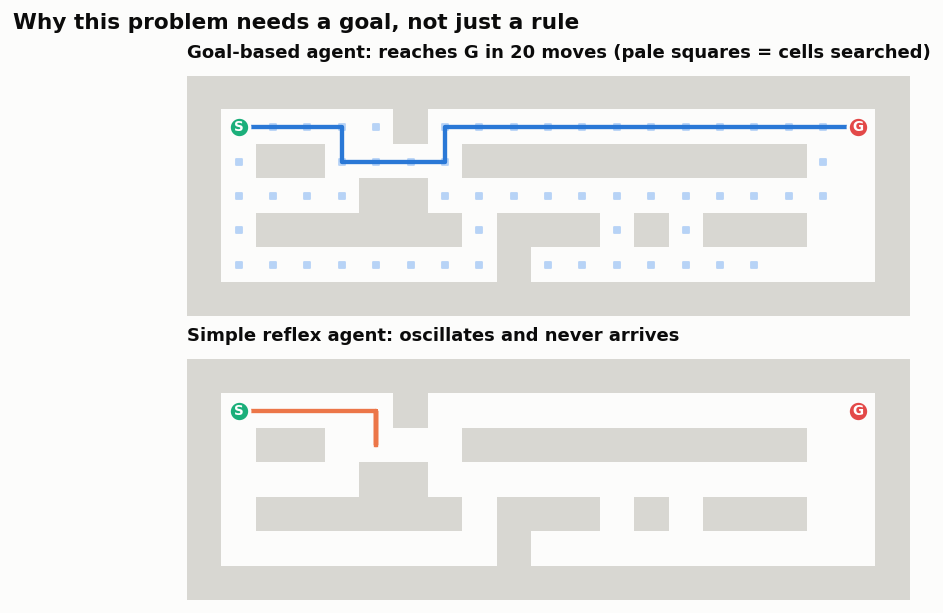

In [6]:
def plot_grid(env, ax, path=None, trail=None, visited=None, title=""):
    grid = np.zeros((env.n_rows, env.n_cols))
    for (r, c) in env.walls:
        grid[r, c] = 1
    cmap = ListedColormap([CELL_COLORS["free"], CELL_COLORS["wall"]])
    ax.imshow(grid, cmap=cmap, interpolation="nearest")

    if visited:
        vs = np.array([p for p in visited if p not in env.walls])
        ax.scatter(vs[:, 1], vs[:, 0], s=10, color="#b7d3f6", marker="s", zorder=2)
    if path:
        ps = np.array(path)
        ax.plot(ps[:, 1], ps[:, 0], color=SERIES["goal-based (BFS)"], lw=2.4, zorder=3)
    if trail:
        ts = np.array(trail)
        ax.plot(ts[:, 1], ts[:, 0], color=SERIES["simple reflex"], lw=2.4,
                zorder=3, alpha=0.9)
    ax.scatter([env.start[1]], [env.start[0]], s=130, color=CELL_COLORS["start"],
               edgecolor=INK["surface"], linewidth=1.8, zorder=5)
    ax.scatter([env.goal[1]], [env.goal[0]], s=130, color=CELL_COLORS["goal"],
               edgecolor=INK["surface"], linewidth=1.8, zorder=5)
    ax.annotate("S", (env.start[1], env.start[0]), ha="center", va="center",
                fontsize=7.5, weight="bold", color="white", zorder=6)
    ax.annotate("G", (env.goal[1], env.goal[0]), ha="center", va="center",
                fontsize=7.5, weight="bold", color="white", zorder=6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    for s in ax.spines.values():
        s.set_visible(False)

fig, axes = plt.subplots(2, 1, figsize=(8.4, 4.6), layout="constrained")
plot_grid(warehouse, axes[0], path=bfs_result.path, visited=bfs_result.visited,
          title=f"Goal-based agent: reaches G in {bfs_result.n_moves} moves "
                f"(pale squares = cells searched)")
plot_grid(warehouse, axes[1], trail=reflex_result.path,
          title="Simple reflex agent: oscillates and never arrives")
fig.suptitle("Why this problem needs a goal, not just a rule", x=0.01, ha="left",
             fontsize=12, color=INK["primary"], weight="semibold")
plt.show()

### Validating the returned path

A path that *looks* right is not a validated path. Four properties must hold, and
each is checked independently of the search that produced it.

In [7]:
def validate_path(env, result):
    """Check a returned path against the environment, independently of the search."""
    checks = {}
    p = result.path
    checks["starts at S"] = bool(p) and p[0] == env.start
    checks["ends at G"] = bool(p) and p[-1] == env.goal
    checks["every cell is passable"] = all(env.passable(c) for c in p)
    checks["every step is one orthogonal move"] = all(
        manhattan(p[i], p[i + 1]) == 1 for i in range(len(p) - 1))
    checks["action list matches the cells"] = len(result.actions) == len(p) - 1
    # replay the action names through the environment and see if we land on G
    cur, replay_ok = env.start, True
    for act in result.actions:
        nxt = dict(env.actions(cur)).get(act)
        if nxt is None:
            replay_ok = False
            break
        cur = nxt
    checks["replaying the actions reaches G"] = replay_ok and cur == env.goal
    # optimality: BFS length must equal the independently computed shortest distance
    dist, seen, q = {env.start: 0}, {env.start}, deque([env.start])
    while q:
        cell = q.popleft()
        for _, nxt in env.actions(cell):
            if nxt not in seen:
                seen.add(nxt); dist[nxt] = dist[cell] + 1; q.append(nxt)
    checks["length equals the true shortest distance"] = (
        dist.get(env.goal) == result.n_moves)
    return checks, dist.get(env.goal)

checks, true_dist = validate_path(warehouse, bfs_result)
print("Independent validation of the returned path:\n")
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print(f"\n  true shortest distance S->G = {true_dist}, agent returned {bfs_result.n_moves}")
assert all(checks.values()), "the returned path failed validation"

Independent validation of the returned path:

  [PASS] starts at S
  [PASS] ends at G
  [PASS] every cell is passable
  [PASS] every step is one orthogonal move
  [PASS] action list matches the cells
  [PASS] replaying the actions reaches G
  [PASS] length equals the true shortest distance

  true shortest distance S->G = 20, agent returned 20


### Testing beyond the supplied map

The handout's map has a solution, so running only that map tests almost nothing.
Three more cases with *known* answers:

In [8]:
TEST_MAPS = {
    "goal adjacent to start": ("#####\n#SG##\n#####", 1),
    "goal walled off": ("#######\n#S....#\n###.###\n#...#G#\n#######", None),
    "two routes, one shorter": ("#########\n#S..#...#\n#.#.#.#.#\n#.#...#.#\n"
                                "#.#####.#\n#......G#\n#########", None),
}

print("| test | path found | moves | expanded | expected | verdict |")
print("|---|:---:|---:|---:|---|:---:|")
for name, (text, expected) in TEST_MAPS.items():
    env = Warehouse.parse(text)
    res = goal_based_agent(env)
    if expected is None and name == "goal walled off":
        ok = (not res.found)
        exp = "no path"
    elif expected is None:
        chk, true_d = validate_path(env, res)
        ok = all(chk.values())
        exp = f"shortest = {true_d}"
    else:
        ok = res.found and res.n_moves == expected
        exp = f"{expected} move(s)"
    print(f"| {name} | {res.found} | {res.n_moves if res.found else '-'} | "
          f"{res.n_expanded} | {exp} | {'PASS' if ok else 'FAIL'} |")
    assert ok, f"test failed: {name}"

# the trivial case where the start already satisfies the goal
trivial = Warehouse(frozenset({(0, 0), (0, 1), (0, 2), (1, 0), (1, 2),
                               (2, 0), (2, 1), (2, 2)}), 3, 3, (1, 1), (1, 1))
res0 = goal_based_agent(trivial)
print(f"| start already at goal | {res0.found} | {res0.n_moves} | "
      f"{res0.n_expanded} | 0 moves | {'PASS' if res0.found and res0.n_moves == 0 else 'FAIL'} |")
assert res0.found and res0.n_moves == 0

print("\nThe 'goal walled off' case matters most: it confirms the agent reports")
print("failure by exhausting the frontier rather than looping forever. A program")
print("that only ever runs on solvable maps has not been tested.")

| test | path found | moves | expanded | expected | verdict |
|---|:---:|---:|---:|---|:---:|
| goal adjacent to start | True | 1 | 1 | 1 move(s) | PASS |
| goal walled off | False | - | 9 | no path | PASS |
| two routes, one shorter | True | 10 | 18 | shortest = 10 | PASS |
| start already at goal | True | 0 | 0 | 0 moves | PASS |

The 'goal walled off' case matters most: it confirms the agent reports
failure by exhausting the frontier rather than looping forever. A program
that only ever runs on solvable maps has not been tested.


---

## Think About It, measured — what happens when the warehouse grows?

The prediction in Task 2 was that BFS stays correct but its cost grows with the
*area* searched, so doubling both dimensions should roughly quadruple the work.
Rather than assert that, the cell below builds a family of warehouses of
increasing size with the same obstacle density and fits the growth curve.

In [9]:
def random_warehouse(n_rows, n_cols, density=0.25, seed=0):
    """A random warehouse with a guaranteed-open border path, so S can reach G."""
    rng = random.Random(seed)
    walls = set()
    for r in range(n_rows):
        for c in range(n_cols):
            edge = r in (0, n_rows - 1) or c in (0, n_cols - 1)
            if edge:
                walls.add((r, c))
            elif rng.random() < density:
                walls.add((r, c))
    start, goal = (1, 1), (n_rows - 2, n_cols - 2)
    # clear a border corridor so a path always exists
    for c in range(1, n_cols - 1):
        walls.discard((1, c)); walls.discard((n_rows - 2, c))
    for r in range(1, n_rows - 1):
        walls.discard((r, n_cols - 2))
    return Warehouse(frozenset(walls), n_rows, n_cols, start, goal)

sizes, expanded, frontiers, moves, times = [], [], [], [], []
for k in range(1, 9):
    n_rows, n_cols = 5 * k + 2, 10 * k + 2
    env = random_warehouse(n_rows, n_cols, seed=k)
    t0 = time.perf_counter()
    res = goal_based_agent(env)
    dt = time.perf_counter() - t0
    free = env.n_rows * env.n_cols - len(env.walls)
    sizes.append(free); expanded.append(res.n_expanded)
    frontiers.append(res.max_frontier); moves.append(res.n_moves)
    times.append(dt * 1000)

print("| free cells | nodes expanded | max frontier | path length | time (ms) |")
print("|---:|---:|---:|---:|---:|")
for s, e, f, m, t in zip(sizes, expanded, frontiers, moves, times):
    print(f"| {s} | {e} | {f} | {m} | {t:.2f} |")

slope = np.polyfit(np.log(sizes), np.log(expanded), 1)[0]
print(f"\nFitted growth: nodes expanded ~ (free cells)^{slope:.2f}")
print("An exponent near 1.0 confirms the prediction: BFS expansion scales with the")
print("AREA it must cover, not with the path length. Doubling both dimensions")
print("quadruples the number of cells, and therefore roughly quadruples the work.")
print(f"Max frontier grows too ({frontiers[0]} -> {frontiers[-1]}), and it is memory,")
print("not time, that fails first on a large warehouse.")

| free cells | nodes expanded | max frontier | path length | time (ms) |
|---:|---:|---:|---:|---:|
| 40 | 38 | 5 | 13 | 0.07 |
| 154 | 147 | 13 | 28 | 0.24 |
| 361 | 359 | 17 | 43 | 0.57 |
| 615 | 611 | 25 | 58 | 1.08 |
| 966 | 956 | 34 | 73 | 1.64 |
| 1361 | 1346 | 37 | 88 | 2.34 |
| 1845 | 1829 | 42 | 103 | 3.73 |
| 2453 | 2439 | 40 | 118 | 4.33 |

Fitted growth: nodes expanded ~ (free cells)^1.01
An exponent near 1.0 confirms the prediction: BFS expansion scales with the
AREA it must cover, not with the path length. Doubling both dimensions
quadruples the number of cells, and therefore roughly quadruples the work.
Max frontier grows too (5 -> 40), and it is memory,
not time, that fails first on a large warehouse.


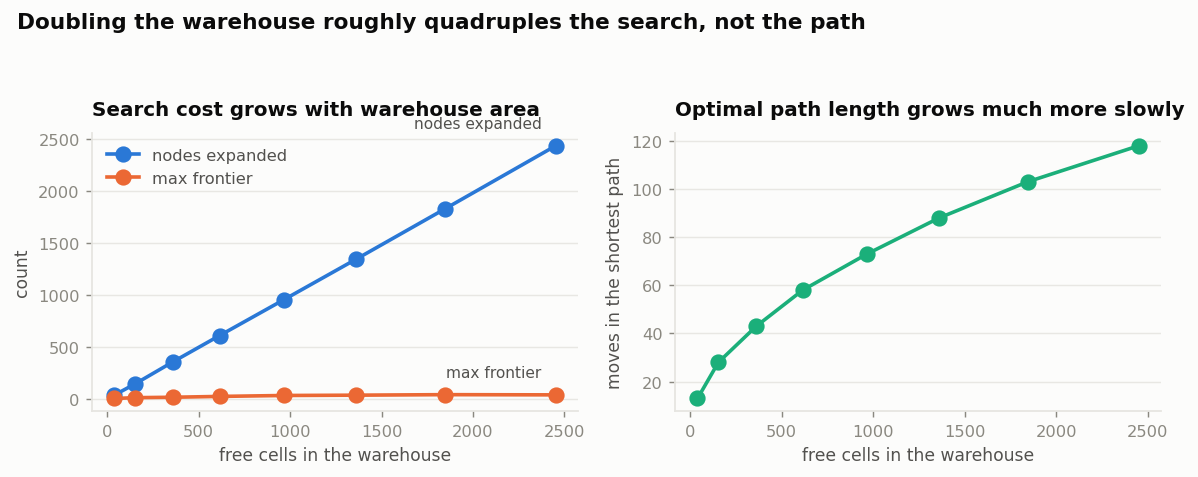

The gap between the two panels is the argument for an informed algorithm:
the answer stays short while the blind search needed to find it explodes.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
axes[0].plot(sizes, expanded, color=SERIES["goal-based (BFS)"], marker="o",
             label="nodes expanded")
axes[0].plot(sizes, frontiers, color=SERIES["simple reflex"], marker="o",
             label="max frontier")
axes[0].annotate("nodes expanded", (sizes[-1], expanded[-1]),
                 textcoords="offset points", xytext=(-8, 10), fontsize=8.5,
                 ha="right", color=INK["secondary"])
axes[0].annotate("max frontier", (sizes[-1], frontiers[-1]),
                 textcoords="offset points", xytext=(-8, 10), fontsize=8.5,
                 ha="right", color=INK["secondary"])
axes[0].legend(loc="upper left")
style(axes[0], "Search cost grows with warehouse area", "free cells in the warehouse",
      "count")

axes[1].plot(sizes, moves, color=SERIES["goal-based (DFS)"], marker="o")
style(axes[1], "Optimal path length grows much more slowly",
      "free cells in the warehouse", "moves in the shortest path")
fig.suptitle("Doubling the warehouse roughly quadruples the search, not the path",
             x=0.02, ha="left", fontsize=12, color=INK["primary"], weight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()
print("The gap between the two panels is the argument for an informed algorithm:")
print("the answer stays short while the blind search needed to find it explodes.")

---

## Summary of results

In [11]:
print("=" * 74)
print("RESULT SUMMARY".center(74))
print("=" * 74)
print(f"\nWarehouse: {warehouse.n_rows} x {warehouse.n_cols}, "
      f"{len(warehouse.walls)} obstacles, S={warehouse.start}, G={warehouse.goal}")
print(f"\n[Task 1/3] Goal-based agent (BFS)")
print(f"  path found          : {bfs_result.found}")
print(f"  path length         : {bfs_result.n_moves} moves (= true shortest distance {true_dist})")
print(f"  nodes expanded      : {bfs_result.n_expanded}")
print(f"  max frontier        : {bfs_result.max_frontier}")
print(f"  all 7 validation checks passed")
print(f"\n[Task 1 Q5] Simple reflex agent on the same map")
print(f"  reached goal        : {reflex_result.found}")
print(f"  outcome             : {reflex_result.note}")
print(f"  -> the comparison is the evidence that this problem needs a goal-based agent")
print(f"\n[Tests] 4 maps with known answers: adjacent goal, walled-off goal,")
print(f"        two-route map, start-is-goal -- all passed")
print(f"\n[Think About It] scaling over 8 warehouse sizes")
print(f"  nodes expanded ~ (free cells)^{slope:.2f}  -> linear in AREA")
print(f"  max frontier {frontiers[0]} -> {frontiers[-1]} as the warehouse grows")
print("\n" + "=" * 74)

                              RESULT SUMMARY                              

Warehouse: 7 x 21, 81 obstacles, S=(1, 1), G=(1, 19)

[Task 1/3] Goal-based agent (BFS)
  path found          : True
  path length         : 20 moves (= true shortest distance 20)
  nodes expanded      : 55
  max frontier        : 5
  all 7 validation checks passed

[Task 1 Q5] Simple reflex agent on the same map
  reached goal        : False
  outcome             : oscillating between (1, 5) and (2, 5) after 7 steps
  -> the comparison is the evidence that this problem needs a goal-based agent

[Tests] 4 maps with known answers: adjacent goal, walled-off goal,
        two-route map, start-is-goal -- all passed

[Think About It] scaling over 8 warehouse sizes
  nodes expanded ~ (free cells)^1.01  -> linear in AREA
  max frontier 5 -> 40 as the warehouse grows



---

## Reflection

### What the LLM contributed, and what I had to verify

The LLM was good at the mechanical parts: the dataclasses, the path-reconstruction
loop, the rendering helper, and the plotting code. Those are tedious to type and
easy to specify precisely, and specifying them precisely is what made the output
checkable.

What it did not do was decide anything. The choice of BFS over A\* came from
noticing that every move costs 1; the decision to mark cells visited on enqueue
came from knowing what goes wrong otherwise; the decision to implement a reflex
agent *as a control* came from wanting question 5 answered with evidence rather
than prose. Left to itself the model reached for A\* — a defensible algorithm,
but selected by association with the phrase "grid navigation" rather than by any
argument about this problem's cost structure.

Both bugs I corrected were in **measurement**, not mechanism: visited-marking
inflated the expansion count, and "expanded" was conflated with "generated". The
path was right in every case. That is the uncomfortable part — the program looked
correct, produced correct output, and still would have reported misleading
numbers in the BFS/A\* comparison that the Search lab builds on.

### What I would keep if this scaled up

The validation function, because it checks the *answer* rather than the
algorithm: it re-derives the shortest distance independently and replays the
action list through the environment. That style of check survives any change of
search strategy. The adversarial maps would survive too — especially the
walled-off one, since "reports failure correctly" is the property most likely to
break and least likely to be noticed.

What would not survive is the exhaustive comparison against a full BFS
ground-truth distance map; on a warehouse large enough to matter, computing the
reference answer is as expensive as the search being tested, and it would have to
become a spot check on sampled goals.

---

## Reference

S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. —
agent types (simple reflex, model-based, goal-based), task-environment
properties, and uninformed search.